# ***Voice Feature Extraction for Parkinson's Disease Detection***

This notebook extracts acoustic features from voice recordings to help identify Parkinson's Disease (PD).

## Background

**Why voice analysis for Parkinson's?**

Parkinson's Disease affects the muscles that control speech. Up to 90% of people with PD develop voice changes, often before other symptoms appear. This makes voice analysis a promising tool for early detection.

## What We Measure

| Feature | What It Measures | Healthy vs PD |
|---------|------------------|---------------|
| **Pitch** | How high/low the voice sounds (Hz) | Varies by gender |
| **Jitter** | Voice shakiness (pitch instability) | PD: Higher (more shaky) |
| **Shimmer** | Volume variations (amplitude instability) | PD: Higher (more unstable) |
| **HNR** | Voice clarity vs breathiness | PD: Lower (more breathy) |

## Data

- **HC_AH**: Healthy Control subjects - sustained "Ahhh" vowel
- **PD_AH**: Parkinson's Disease subjects - sustained "Ahhh" vowel

---
## Setup: Import Libraries

In [159]:
import parselmouth                    # Voice analysis library (Python wrapper for Praat)
from parselmouth.praat import call    # For jitter/shimmer calculations
import glob                           # Find files matching a pattern
import pandas as pd                   # Data manipulation
import numpy as np                    # Numerical operations
import os                             # File/folder operations

---
## Feature 1: Pitch (Fundamental Frequency)

**What is it?** How high or low your voice sounds.

**How it works:** When you speak, your vocal cords vibrate. Pitch is the speed of these vibrations measured in Hertz (Hz).


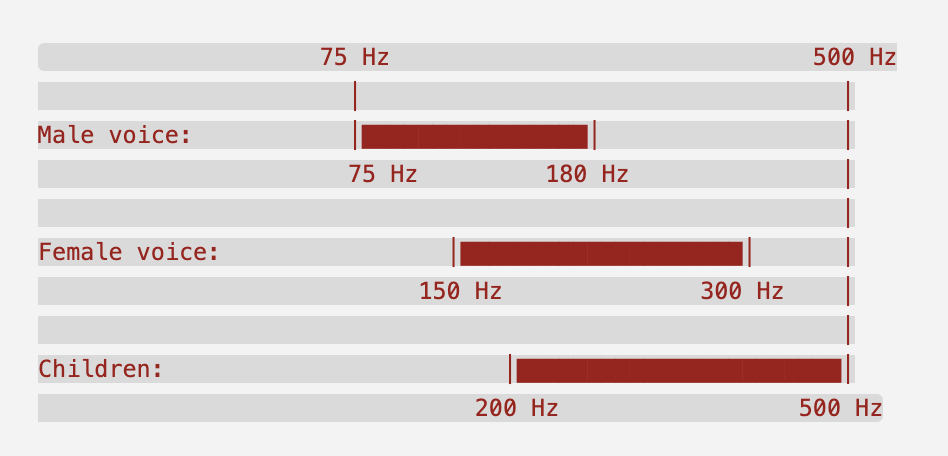

- Min pitch: 75 Hz, Lowest expected human voice (deep male)
- Max pitch: 500 Hz, Highest expected voice (female/child)


In [158]:
def extract_pitch_mean(voice):
    """
    Calculate the average pitch (fundamental frequency) of a voice recording.
    
    Parameters:
        voice: parselmouth.Sound object
    
    Returns:
        float: Mean pitch in Hz (e.g., 120.5 Hz)
    """
    pitch = voice.to_pitch()                           # Analyze pitch over time
    pitch_values = pitch.selected_array['frequency']   # Get all pitch measurements
    voiced_pitch = pitch_values[pitch_values > 0]      # Remove silent frames (0 = no voice)
    mean_pitch = np.mean(voiced_pitch)                 # Calculate average
    return round(mean_pitch, 2)

---
## Feature 2: Jitter (Pitch Instability)
**What is it?** 
- How much your voice "wobbles" in pitch from one vocal cord vibration to the next.
- Like when someone's voice trembles when nervous

**Analogy:** 
- When you speak, your vocal cords open and close rapidly. Each opening/closing cycle is a glottal pulse
- Imagine a metronome that should tick every 1 second. If it ticks at 1.0s, 1.02s, 0.98s, 1.01s... that variation is like jitter.

**Why it matters for PD:** Parkinson's affects muscle control, causing the vocal cords to vibrate less steadily → higher jitter.

**Normal value:** < 1% (or 0.01)

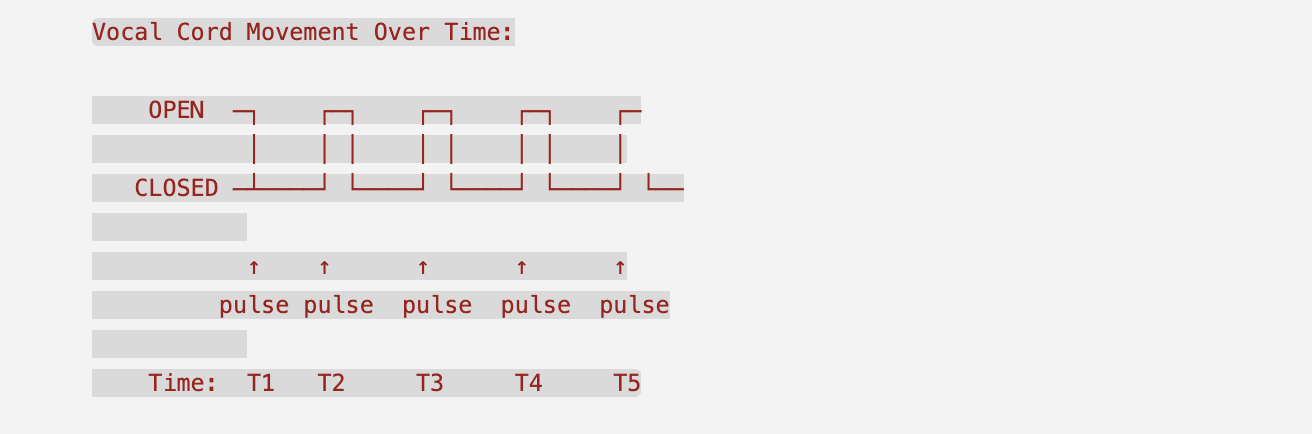

PointProcess detects the timing of each pulse (T1, T2, T3...).

The period is the time between consecutive pulses:

Period 1 = T2 - T1
Period 2 = T3 - T2
Period 3 = T4 - T3

***Jitter measures how much these periods vary from each other.***

In [161]:
def extract_jitter_local(voice):
    """
    Calculate jitter (pitch instability) of a voice recording.
    
    Parameters:
        voice: parselmouth.Sound object
    
    Returns:
        float: Jitter as a ratio (e.g., 0.005 = 0.5%)
               Higher values = more voice instability
    """
    # Detect each vocal cord vibration (glottal pulse)
    # 75-500 Hz = range of human voice pitch
    point_process = call(voice, "To PointProcess (periodic, cc)", 75, 500)
    
    # Calculate jitter from the timing variations between pulses
    jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    
    return round(jitter, 5)

---
## Feature 3: Shimmer (Volume Instability)

**What is it?** How much your voice volume varies from one vibration to the next.

**Analogy:** 
- Like jitter, but for loudness/intensity instead of pitch. Imagine speaking into a microphone with an unstable connection - the volume keeps changing.
- Like if your voice unexpectedly gets quieter or louder

**Why it matters for PD:** Weakened muscle control causes inconsistent air pressure → fluctuating volume → higher shimmer.

**Normal value:** < 3.8% (or 0.038)

**How Shimmer is Measured:**

```
Sound Wave Amplitude (Volume):

        ▲
    A1  │   █           █           
        │  █ █         █ █         
    A2  │ █   █       █   █   █   
        │█     █     █     █ █ █ 
    A3  │       █   █       █   
        └──────────────────────► Time
          Cycle1  Cycle2  Cycle3
          
    Amplitude: A1=10   A2=11   A3=9
    
    Shimmer = average amplitude difference / mean amplitude
```

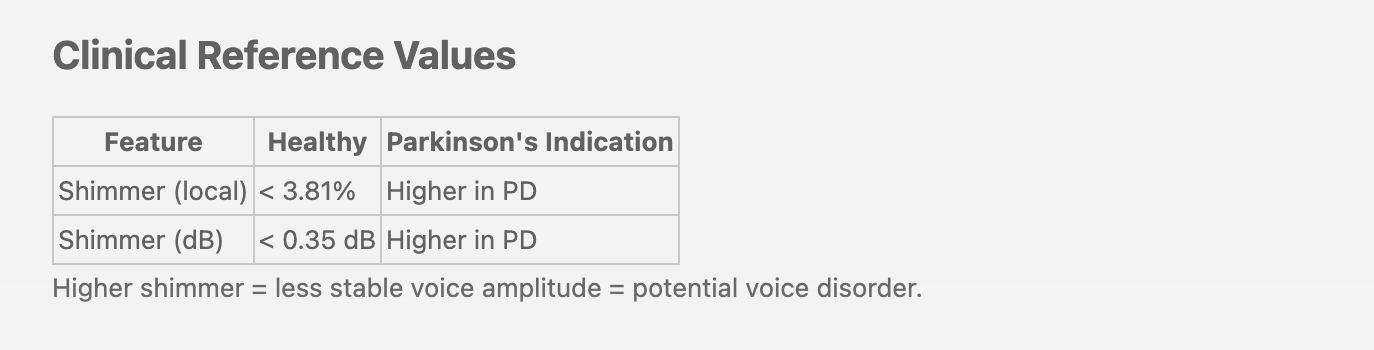

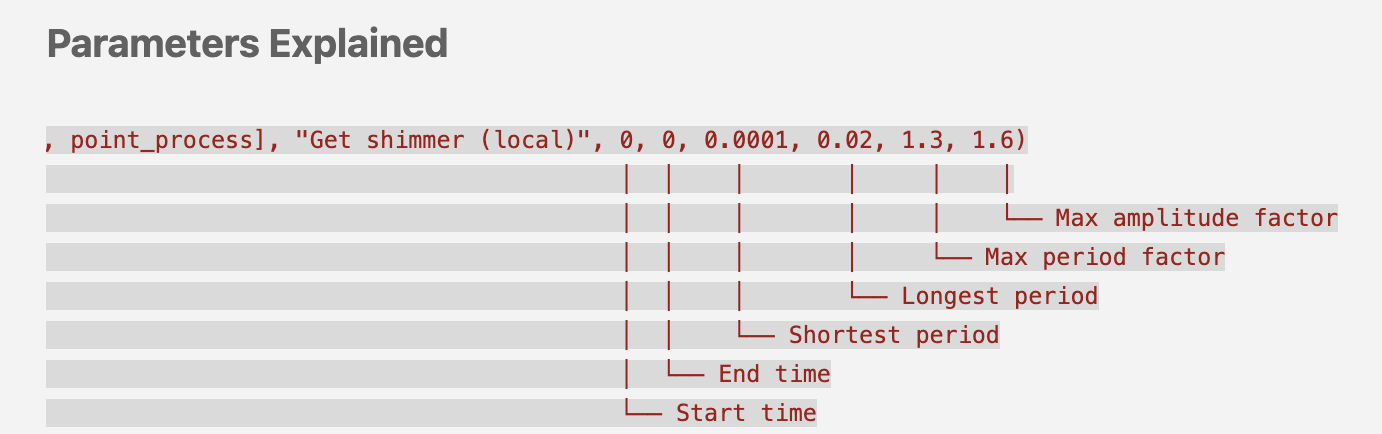

In [162]:
def extract_shimmer_local(voice):
    """
    Calculate shimmer (volume instability) of a voice recording.
    
    Parameters:
        voice: parselmouth.Sound object
    
    Returns:
        float: Shimmer as a ratio (e.g., 0.03 = 3%)
               Higher values = more volume instability
    """
    # Detect vocal cord vibrations
    point_process = call(voice, "To PointProcess (periodic, cc)", 75, 500)
    
    # Calculate shimmer - needs both the sound AND timing information
    # The extra parameter (1.6) filters out extreme amplitude outliers
    shimmer = call([voice, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    
    return round(shimmer, 5)

---
## Feature 4: HNR (Harmonics-to-Noise Ratio)

**What is it?** How "clear" vs "breathy/hoarse" your voice sounds.

**Analogy:** Think of a flute (clear, pure tone) vs wind blowing (noisy). A healthy voice is more like the flute; a Parkinson's voice often has more "wind noise."

**Why it matters for PD:** Incomplete vocal cord closure lets air escape → breathy voice → lower HNR.

**Normal value:** 
- > 20 dB (decibels)
- Clear voice = high HNR
- Breathy/hoarse voice = low HNR

**How HNR is Measured:**  

```
Voice Signal = Harmonics (clear tone) + Noise (breathiness)

HEALTHY VOICE (HNR ~25 dB):     PARKINSONS VOICE (HNR ~15 dB):
│                               │
│  ████  Harmonics (strong)     │  ██    Harmonics (weak)
│  ████                         │  ██
│  ░░    Noise (low)            │  ░░░░  Noise (high)
│                               │  ░░░░
└─────────────                  └─────────────

HNR = 10 × log₁₀(Harmonic Energy / Noise Energy)
```


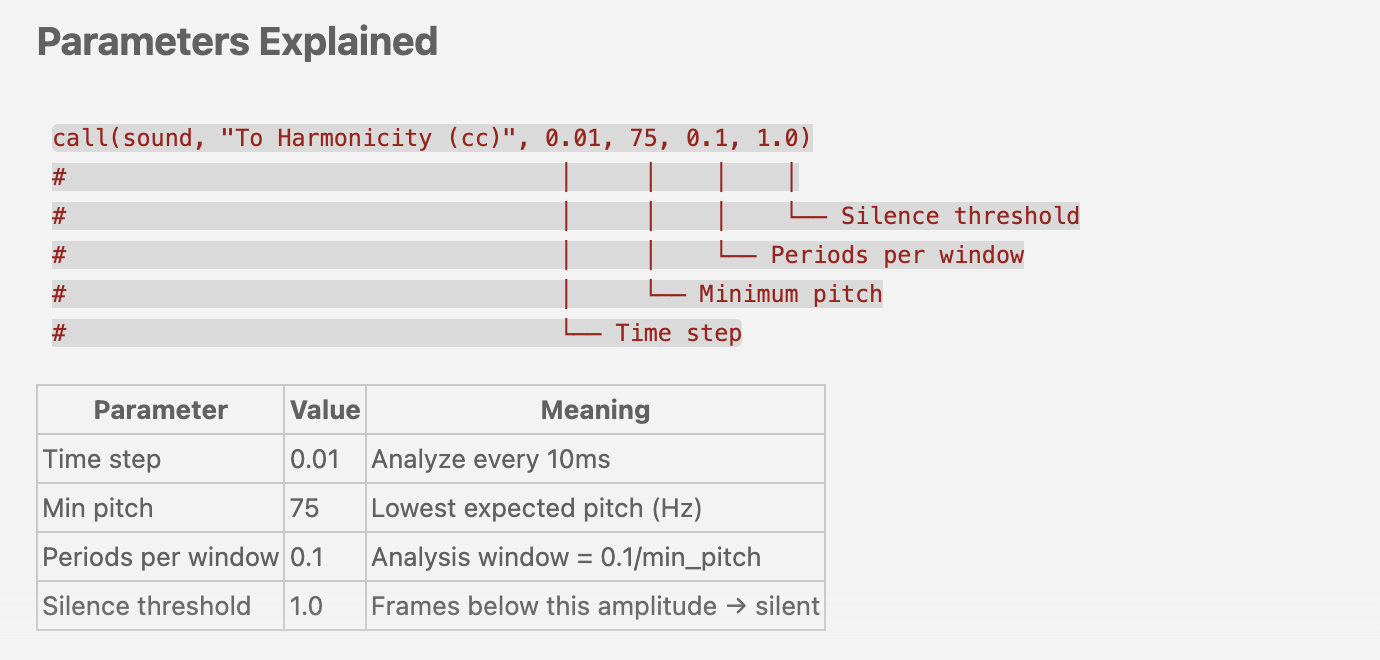

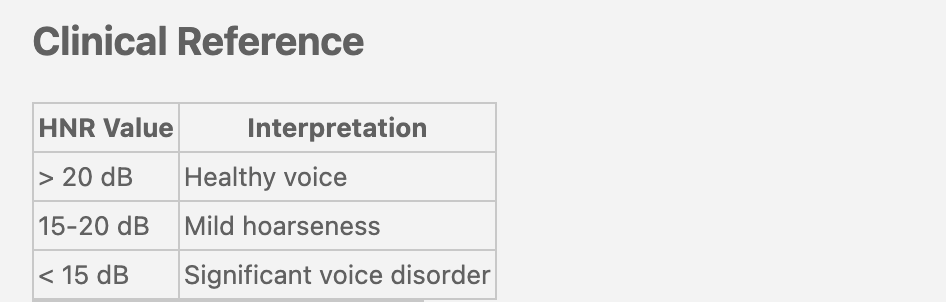

In [163]:
def extract_HNR_mean(voice):
    """
    Calculate HNR (voice clarity) of a voice recording.
    
    Parameters:
        voice: parselmouth.Sound object
    
    Returns:
        float: HNR in decibels (e.g., 22.5 dB)
               Higher values = clearer voice
               Lower values = breathier/hoarser voice
    """
    harmonicity = voice.to_harmonicity()                        # Analyze harmonics vs noise
    hnr_values = harmonicity.values[harmonicity.values != -200] # Remove unvoiced frames (-200 = no voice)
    hnr_mean = np.mean(hnr_values)                              # Calculate average
    return round(hnr_mean, 2)

---
## Processing Functions

These functions process all audio files and save results.

In [168]:
def extract_subject_id(file_path,data_group_name):
    """
    Extract subject ID and group from the audio file path.
    
    Example:
        'data/HC_AH/AH_121A_xxx.wav' → '121A_HC'
        'data/PD_AH/AH_456K_xxx.wav' → '456K_PD'
    
    Parameters:
        file_path: Path to audio file
    
    Returns:
        str: Subject ID with group label (e.g., '121A_HC')
    """
    filename = file_path.split('/')[-1]
    return filename.split('_')[1] + '_' + data_group_name

In [169]:
def extract_voice_features(audio_files, data_group_name, result_file_name):
    """
    Extract voice features from all audio files and save to CSV.
    
    Parameters:
        audio_files: List of audio file paths
        result_file_name: Name for output CSV file (without .csv extension)
    
    Returns:
        DataFrame with columns: ID, Pitch, Jitter, Shimmer, HNR
    """
    
    results = pd.DataFrame({'ID':[],'Pitch':[],'Jitter':[],'Shimmer':[],'HNR':[]})
    
    for audio_file in audio_files:
        voice = parselmouth.Sound(audio_file)
        mean_pitch = extract_pitch_mean(voice)
        jitter = extract_jitter_local(voice)
        shimmer = extract_shimmer_local(voice)
        hnr = extract_HNR_mean(voice)
        
        results.loc[len(results)] = {"ID":extract_subject_id(audio_file,data_group_name), "Pitch":mean_pitch, "Jitter":jitter, "Shimmer":shimmer, "HNR":hnr}
        
    results.to_csv(f'results/{result_file_name}.csv')
    
    return results

---
## Run Feature Extraction

Process both Healthy Control (HC) and Parkinson's Disease (PD) voice recordings.

In [172]:
# load the voices in .wav format for the both groups
hc_audio_files = glob.glob('data/HC_AH/*.wav')
pd_audio_files = glob.glob('data/PD_AH/*.wav')


print(f"Found {len(hc_audio_files)} Healthy Control recordings")
print(f"Found {len(pd_audio_files)} Parkinson's Disease recordings")

Found 41 Healthy Control recordings
Found 40 Parkinson's Disease recordings


In [174]:
# create result dir
os.mkdir('results')

# Extract features from Healthy Controls
extract_voice_features(hc_audio_files,"HC","HC_result")
extract_voice_features(hc_audio_files,"PD","PD_result")

,ID,Pitch,Jitter,Shimmer,HNR
0,121A_PD,234.25,0.00468,0.04797,23.15
1,596S_PD,197.48,0.00309,0.04183,23.06
2,904H_PD,239.74,0.00390,0.04210,21.64
3,292J_PD,89.80,0.00785,0.11016,11.98
4,456K_PD,137.91,0.00370,0.03268,21.09
5,888A_PD,83.32,0.00983,0.11034,8.54
6,942A_PD,114.69,0.00713,0.06605,16.26
7,444B_PD,176.38,0.00428,0.03654,21.77
8,789Y_PD,274.57,0.00325,0.06774,18.84
9,469Z_PD,106.74,0.01513,0.12402,13.72
